In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
print('variance of Doors:', df['Doors'].var())

print('variance of Cylinders:', df['Cylinders'].var())

print('variance of Gears:', df['Gears'].var())

print('variance of Automatic:', df['Automatic'].var())

## variance of Cylinders, Gears and Automatic columns data is either 0 or around 0, we need to drop those columns from Dataset.


variance of Doors: 0.9075927130142623
variance of Cylinders: 0.0
variance of Gears: 0.03553618743509323
variance of Automatic: 0.052643327865829814


In [7]:
df_Toyota_Corolla=df.drop(['Cylinders','Gears','Automatic'],axis=1)
df_Toyota_Corolla

,Price,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight
0,13500,23,46986,Diesel,90,2000,3,1165
1,13750,23,72937,Diesel,90,2000,3,1165
2,13950,24,41711,Diesel,90,2000,3,1165
3,14950,26,48000,Diesel,90,2000,3,1165
4,13750,30,38500,Diesel,90,2000,3,1170
...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,1300,3,1025
1432,10845,72,19000,Petrol,86,1300,3,1015
1433,8500,71,17016,Petrol,86,1300,3,1015
1434,7250,70,16916,Petrol,86,1300,3,1015


In [8]:
df_Toyota_Corolla.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'cc', 'Doors', 'Weight'], dtype='object')

In [9]:
df_Toyota_Corolla.info()
df_Toyota_Corolla.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   cc         1436 non-null   int64 
 6   Doors      1436 non-null   int64 
 7   Weight     1436 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 89.9+ KB


,Price,Age_08_04,KM,HP,cc,Doors,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,1576.85585,4.033426,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,424.38677,0.952677,52.64112
min,4350.000000,1.000000,1.000000,69.000000,1300.00000,2.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,1400.00000,3.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,1600.00000,4.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,1600.00000,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,16000.00000,5.000000,1615.00000


In [10]:
df_Toyota_Corolla.isnull().sum()   ## NO NULL values in dataset

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
cc,0
Doors,0
Weight,0


In [11]:
df_Toyota_Corolla.duplicated().sum()   ## there is one duplicate record so drop it.

np.int64(1)

In [12]:
df_Toyota_Corolla.drop_duplicates(inplace=True)    ### Once I drop the duplicate row here I am commiting and using it same in next steps.

In [13]:
df_Toyota_Corolla.duplicated().sum()

np.int64(0)

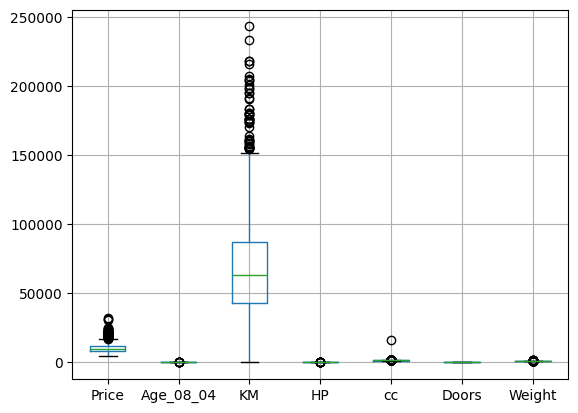

In [14]:
## Outlier detection using boxplot

df_Toyota_Corolla.boxplot()
plt.show()

In [15]:
## this is a function to replace the Outliers with lowerbound and upper bound values, this technique called Capping

def outlier_capping(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[column]=df[column].apply(lambda x:lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)

## Calling outlier_Capping method for each column which are only Integer and Float datatypes
for col in df_Toyota_Corolla.select_dtypes(include=['int','float']).columns:
  outlier_capping(df_Toyota_Corolla,col)

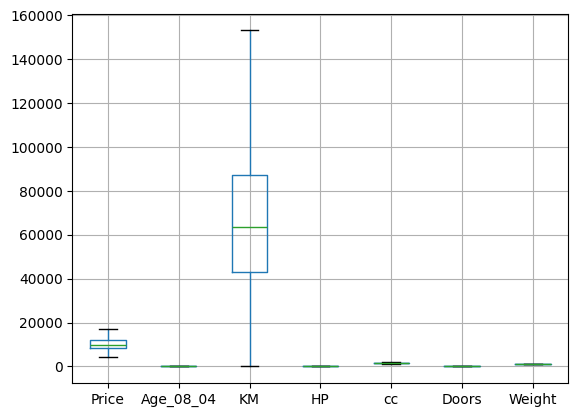

,Price,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight
0,13500.0,23.0,46986.0,Diesel,90.0,1900.0,3,1152.5
1,13750.0,23.0,72937.0,Diesel,90.0,1900.0,3,1152.5
2,13950.0,24.0,41711.0,Diesel,90.0,1900.0,3,1152.5
3,14950.0,26.0,48000.0,Diesel,90.0,1900.0,3,1152.5
4,13750.0,30.0,38500.0,Diesel,90.0,1900.0,3,1152.5
...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,Petrol,86.0,1300.0,3,1025.0
1432,10845.0,72.0,19000.0,Petrol,86.0,1300.0,3,1015.0
1433,8500.0,71.0,17016.0,Petrol,86.0,1300.0,3,1015.0
1434,7250.0,70.0,16916.0,Petrol,86.0,1300.0,3,1015.0


In [16]:
df_Toyota_Corolla.boxplot()
plt.show()
df_Toyota_Corolla          ## why the row count again showing  1435 after dropping the duplicate here and that is reflecting as Nan in onehot encoder join.

In [ ]:
# num_cols=df.select_dtypes(include=['int','float']).columns
# num_cols

# correl=df[num_cols].corr()
# correl

In [17]:
# df = pd.get_dummies(df,dtype='int')

from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder()

df1=pd.DataFrame(one_hot.fit_transform(df_Toyota_Corolla[['Fuel_Type']]).toarray(),columns=['Diesel', 'Petrol', 'CNG'])
print(df1.shape)
print(df_Toyota_Corolla.shape)
df1

(1435, 3)
(1435, 8)


,Diesel,Petrol,CNG
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
1430,0.0,0.0,1.0
1431,0.0,0.0,1.0
1432,0.0,0.0,1.0
1433,0.0,0.0,1.0


In [18]:
df=df_Toyota_Corolla.join(df1)
df

,Price,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight,Diesel,Petrol,CNG
0,13500.0,23.0,46986.0,Diesel,90.0,1900.0,3,1152.5,0.0,1.0,0.0
1,13750.0,23.0,72937.0,Diesel,90.0,1900.0,3,1152.5,0.0,1.0,0.0
2,13950.0,24.0,41711.0,Diesel,90.0,1900.0,3,1152.5,0.0,1.0,0.0
3,14950.0,26.0,48000.0,Diesel,90.0,1900.0,3,1152.5,0.0,1.0,0.0
4,13750.0,30.0,38500.0,Diesel,90.0,1900.0,3,1152.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,Petrol,86.0,1300.0,3,1025.0,0.0,0.0,1.0
1432,10845.0,72.0,19000.0,Petrol,86.0,1300.0,3,1015.0,0.0,0.0,1.0
1433,8500.0,71.0,17016.0,Petrol,86.0,1300.0,3,1015.0,0.0,0.0,1.0
1434,7250.0,70.0,16916.0,Petrol,86.0,1300.0,3,1015.0,0.0,0.0,1.0


In [19]:
df.drop('Fuel_Type',axis=1,inplace=True)
df

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Diesel,Petrol,CNG
0,13500.0,23.0,46986.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
1,13750.0,23.0,72937.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
2,13950.0,24.0,41711.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
3,14950.0,26.0,48000.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
4,13750.0,30.0,38500.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,86.0,1300.0,3,1025.0,0.0,0.0,1.0
1432,10845.0,72.0,19000.0,86.0,1300.0,3,1015.0,0.0,0.0,1.0
1433,8500.0,71.0,17016.0,86.0,1300.0,3,1015.0,0.0,0.0,1.0
1434,7250.0,70.0,16916.0,86.0,1300.0,3,1015.0,0.0,0.0,1.0


In [20]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
HP,0
cc,0
Doors,0
Weight,0
Diesel,1
Petrol,1
CNG,1


In [21]:
df.dropna(inplace=True)
df

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Diesel,Petrol,CNG
0,13500.0,23.0,46986.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
1,13750.0,23.0,72937.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
2,13950.0,24.0,41711.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
3,14950.0,26.0,48000.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
4,13750.0,30.0,38500.0,90.0,1900.0,3,1152.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1430,8450.0,80.0,23000.0,86.0,1300.0,3,1015.0,0.0,0.0,1.0
1431,7500.0,69.0,20544.0,86.0,1300.0,3,1025.0,0.0,0.0,1.0
1432,10845.0,72.0,19000.0,86.0,1300.0,3,1015.0,0.0,0.0,1.0
1433,8500.0,71.0,17016.0,86.0,1300.0,3,1015.0,0.0,0.0,1.0


In [22]:
from sklearn.preprocessing import StandardScaler

std_sca=StandardScaler()
df[['Weight','KM','cc','Age_08_04','HP']]=std_sca.fit_transform(df[['Weight','KM','cc','Age_08_04','HP']])
df

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Diesel,Petrol,CNG
0,13500.0,-1.780480,-0.597060,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
1,13750.0,-1.780480,0.151251,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
2,13950.0,-1.726491,-0.749168,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
3,14950.0,-1.618512,-0.567821,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
4,13750.0,-1.402555,-0.841759,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1430,8450.0,1.296911,-1.288711,-1.147834,-1.530343,3,-1.418677,0.0,0.0,1.0
1431,7500.0,0.703028,-1.359531,-1.147834,-1.530343,3,-1.153450,0.0,0.0,1.0
1432,10845.0,0.864996,-1.404053,-1.147834,-1.530343,3,-1.418677,0.0,0.0,1.0
1433,8500.0,0.811007,-1.461263,-1.147834,-1.530343,3,-1.418677,0.0,0.0,1.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1434 entries, 0 to 1434
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1434 non-null   float64
 1   Age_08_04  1434 non-null   float64
 2   KM         1434 non-null   float64
 3   HP         1434 non-null   float64
 4   cc         1434 non-null   float64
 5   Doors      1434 non-null   int64  
 6   Weight     1434 non-null   float64
 7   Diesel     1434 non-null   float64
 8   Petrol     1434 non-null   float64
 9   CNG        1434 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 123.2 KB


In [25]:
# num_cols=df2.select_dtypes(include=['int','float']).columns
# num_cols

corr=df.corr()        ### Automatic, Cylinders and Gears columns are showing Nan here. this is another big concern.
corr

,Price,Age_08_04,KM,HP,cc,Doors,Weight,Diesel,Petrol,CNG
Price,1.000000,-0.895250,-0.610678,0.255157,0.129624,0.184011,0.509336,-0.042721,-0.008740,0.022651
Age_08_04,-0.895250,1.000000,0.533061,-0.130187,-0.136888,-0.147582,-0.477495,-0.004394,-0.081548,0.079353
KM,-0.610678,0.533061,1.000000,-0.329297,0.259365,-0.035297,0.002621,0.147714,0.350160,-0.383875
HP,0.255157,-0.130187,-0.329297,1.000000,0.098093,0.119721,0.024323,-0.068372,-0.208856,0.222359
cc,0.129624,-0.136888,0.259365,0.098093,1.000000,0.138310,0.717954,0.088063,0.326250,-0.341067
Doors,0.184011,-0.147582,-0.035297,0.119721,0.138310,1.000000,0.380652,0.030139,0.040541,-0.048809
Weight,0.509336,-0.477495,0.002621,0.024323,0.717954,0.380652,1.000000,0.056082,0.276762,-0.283097
Diesel,-0.042721,-0.004394,0.147714,-0.068372,0.088063,0.030139,0.056082,1.000000,-0.037854,-0.298668
Petrol,-0.008740,-0.081548,0.350160,-0.208856,0.326250,0.040541,0.276762,-0.037854,1.000000,-0.942367
CNG,0.022651,0.079353,-0.383875,0.222359,-0.341067,-0.048809,-0.283097,-0.298668,-0.942367,1.000000


<Axes: >

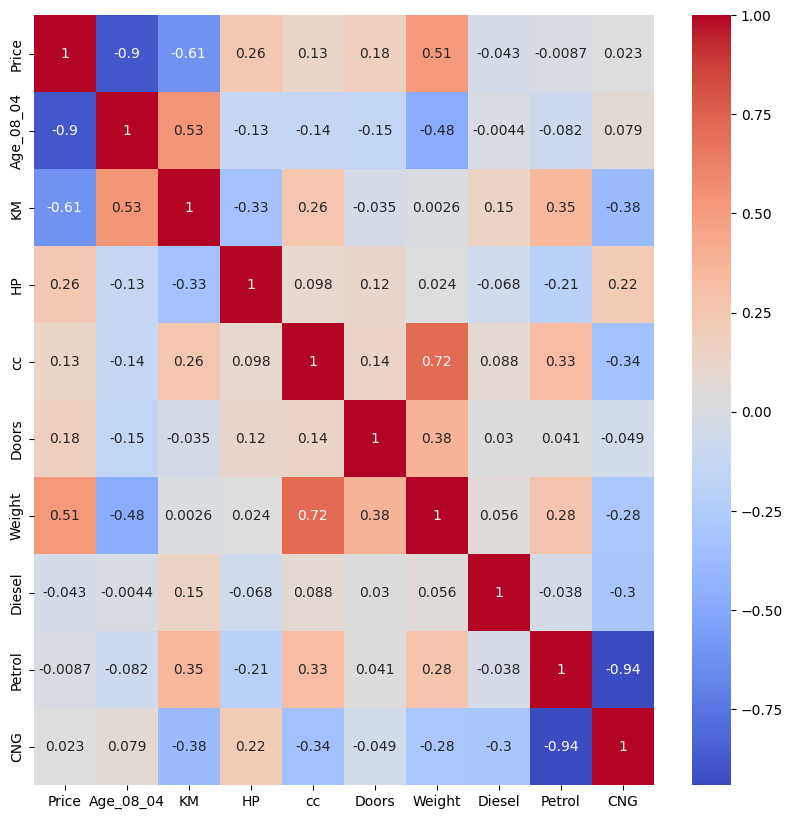

In [26]:
plt.figure(figsize=(10,10))

sns.heatmap(corr,annot=True,cmap='coolwarm')

In [36]:
features=df.drop('Price',axis=1)
features

,Age_08_04,KM,HP,cc,Doors,Weight,Diesel,Petrol,CNG
0,-1.780480,-0.597060,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
1,-1.780480,0.151251,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
2,-1.726491,-0.749168,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
3,-1.618512,-0.567821,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
4,-1.402555,-0.841759,-0.843513,2.024481,3,2.228192,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
1430,1.296911,-1.288711,-1.147834,-1.530343,3,-1.418677,0.0,0.0,1.0
1431,0.703028,-1.359531,-1.147834,-1.530343,3,-1.153450,0.0,0.0,1.0
1432,0.864996,-1.404053,-1.147834,-1.530343,3,-1.418677,0.0,0.0,1.0
1433,0.811007,-1.461263,-1.147834,-1.530343,3,-1.418677,0.0,0.0,1.0


In [37]:
target=df['Price']
target

,Price
0,13500.0
1,13750.0
2,13950.0
3,14950.0
4,13750.0
...,...
1430,8450.0
1431,7500.0
1432,10845.0
1433,8500.0


In [38]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.7,random_state=100)

In [39]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(430, 9)
(1004, 9)
(430,)
(1004,)


In [ ]:
## Model 1:

lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
b1=lin_reg.coef_
b1

array([-1922.39754887,  -556.03779893,   272.37209195,  -430.48882204,
        -100.13231406,  1014.12249317,     2.56314006,     9.23810386,
         -11.80124392])

In [ ]:
intercept=lin_reg.intercept_
intercept

np.float64(10883.371480367958)

In [ ]:
y_pred=lin_reg.predict(x_train)
y_test

,Price
57,15250.0
337,12200.0
464,8750.0
1142,7950.0
714,8450.0
...,...
754,9950.0
1238,7750.0
380,7000.0
1132,6640.0


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_train,y_pred)

0.860634411219169

In [ ]:
y_pred1 = lin_reg.predict(x_test)
y_pred1

array([15313.80623293, 12160.77939641, 10245.43519072, ...,
        8977.4773515 ,  8001.20195143, 12612.60411159])

In [ ]:
r2_score(y_test,y_pred1)

0.8583534747940357

<Axes: xlabel='Price'>

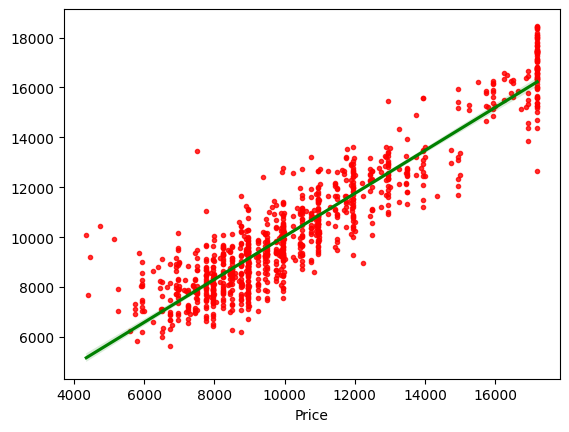

In [ ]:
sns.regplot(data=df,x=y_test,y=y_pred1,scatter_kws={'color':'r','s':9},line_kws={'color':'green'})

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
mean_absolute_error(y_test,y_pred1)

838.5481598704794

In [ ]:
mse=mean_squared_error(y_test,y_pred1)
mse

1257400.9482095093

In [ ]:
round(mean_absolute_percentage_error(y_test,y_pred1)*100,2)

8.88

In [ ]:
rmse=np.sqrt(mse).round(2)
rmse

np.float64(1121.34)

In [ ]:
r_squared=r2_score(y_test,y_pred1)
r_squared

0.8583534747940357

In [ ]:
df.shape
N=1435
k=9
adj_r_squared=1-((1-r_squared)*(N-1)/(N-k-1))
adj_r_squared

0.8574588651611559

In [ ]:
## r_squared > adj_r_squared so the model performance is good.

In [ ]:
## Model 2:

features2=df.drop(['Price','HP','cc'],axis=1)
features2

,Age_08_04,KM,Doors,Weight,Diesel,Petrol,CNG
0,-1.780480,-0.597060,3,2.228192,0.0,1.0,0.0
1,-1.780480,0.151251,3,2.228192,0.0,1.0,0.0
2,-1.726491,-0.749168,3,2.228192,0.0,1.0,0.0
3,-1.618512,-0.567821,3,2.228192,0.0,1.0,0.0
4,-1.402555,-0.841759,3,2.228192,0.0,1.0,0.0
...,...,...,...,...,...,...,...
1430,1.296911,-1.288711,3,-1.418677,0.0,0.0,1.0
1431,0.703028,-1.359531,3,-1.153450,0.0,0.0,1.0
1432,0.864996,-1.404053,3,-1.418677,0.0,0.0,1.0
1433,0.811007,-1.461263,3,-1.418677,0.0,0.0,1.0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(features2,target,test_size=0.7,random_state=100)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(430, 7)
(1004, 7)
(430,)
(1004,)


In [ ]:
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
print('coefficient:',lin_reg.coef_)
print('intercept:',lin_reg.intercept_)

coefficient: [-2010.89916444  -691.92741397     8.25046011   642.23037914
  -140.71301248    53.8189807     86.89403178]
intercept: 10372.929969845314


In [ ]:
y_pred=lin_reg.predict(x_train)
# y_pred

In [ ]:
y_pred2=lin_reg.predict(x_test)
y_pred2

array([14955.47429673, 12442.9236336 , 10544.33647913, ...,
        9692.61581553,  7800.93680094, 12716.17009156])

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred2)

0.8450956915567785

<Axes: xlabel='Price'>

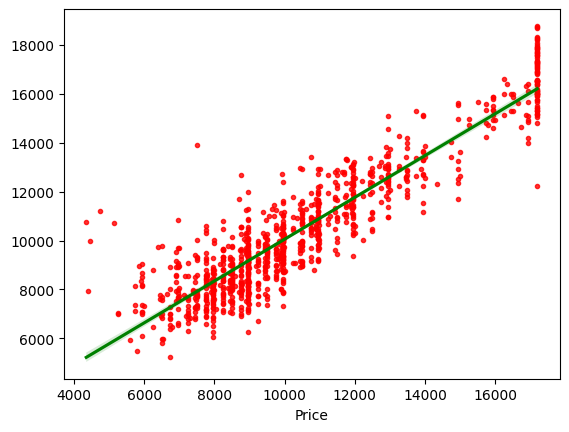

In [ ]:
sns.regplot(data=df,x=y_test,y=y_pred2,scatter_kws={'color':'r','s':9},line_kws={'color':'green'})

In [ ]:
## Model 3:

features3=df.drop(['Price','HP','cc','Doors','Diesel','Petrol','CNG'],axis=1)
features3

,Age_08_04,KM,Weight
0,-1.780480,-0.597060,2.228192
1,-1.780480,0.151251,2.228192
2,-1.726491,-0.749168,2.228192
3,-1.618512,-0.567821,2.228192
4,-1.402555,-0.841759,2.228192
...,...,...,...
1430,1.296911,-1.288711,-1.418677
1431,0.703028,-1.359531,-1.153450
1432,0.864996,-1.404053,-1.418677
1433,0.811007,-1.461263,-1.418677


In [ ]:
target

,Price
0,13500.0
1,13750.0
2,13950.0
3,14950.0
4,13750.0
...,...
1430,8450.0
1431,7500.0
1432,10845.0
1433,8500.0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(features3,target,test_size=0.7,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(430, 3)
(1004, 3)
(430,)
(1004,)


In [ ]:
lin_reg3=LinearRegression()
lin_reg3.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lin_reg3.predict(x_train)

In [ ]:
y_pred2=lin_reg3.predict(x_test)
y_pred2

array([14940.89114687, 12450.00781584, 10566.64901326, ...,
        9703.34891378,  7782.25212761, 12705.80892134])

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred2)

0.8444854839135361

<Axes: xlabel='Price'>

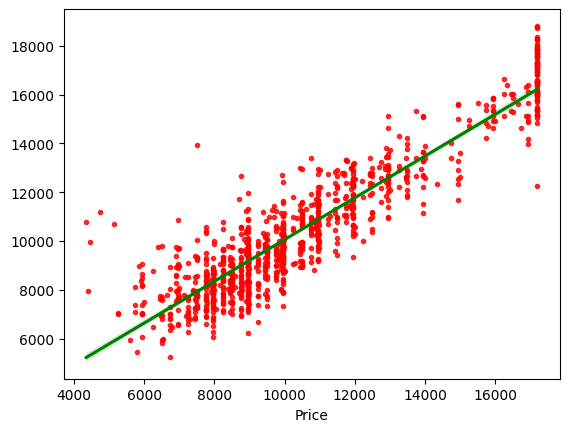

In [ ]:
sns.regplot(data=df,x=y_test,y=y_pred2,scatter_kws={'color':'r','s':9},line_kws={'color':'green'})

In [32]:
import statsmodels.formula.api as sfa

statsmodel1 = sfa.ols(formula='Price~Age_08_04+KM+Doors+Weight+Diesel',data=df).fit()
statsmodel1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     1638.
Date:                Sun, 07 Sep 2025   Prob (F-statistic):               0.00
Time:                        05:51:40   Log-Likelihood:                -12137.
No. Observations:                1434   AIC:                         2.429e+04
Df Residuals:                    1428   BIC:                         2.432e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.044e+04    142.800     73.136      0.000    1.02e+04    1.07e+04
Age_08_04  -1996.6411     43.813    -45.572      0.000   -2082.585   -1910.697
KM          -745.5587     38.909    -19.162      0.000    -821.884    -669.234
Doors         15.1247     34.616      0.437      0.662     -52.778      83.028
Weight       562.1705     39.488     14.237      0.000     484.710     639.631
Diesel      -533.5668    284.977     -1.872      0.061   -1092.585      25.452
==============================================================================
Omnibus:                      139.329   Durbin-Watson:                   1.653
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              419.914
Skew:                          -0.489   Prob(JB):                     6.56e-92
Kurtosis:                       5.464   Cond. No.                         40.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
statsmodel1.rsquared

np.float64(0.8515234131438353)

In [34]:
statsmodel1.rsquared_adj

np.float64(0.8510035371394369)

In [ ]:
## rsquared > rsquared_adj so the model performance is good.

In [42]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import Lasso,Ridge,ElasticNet
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [51]:
## Lasso Regularization Technique

lasso = Lasso(alpha=5)

In [52]:
lasso.fit(x_train,y_train)

Lasso(alpha=5)

In [53]:
lasso.coef_

array([-1931.40268952,  -553.49901081,   261.95206305,  -401.74130688,
         -85.61757923,   982.09525032,    -0.        ,     0.        ,
          -0.        ])

In [54]:
lasso.intercept_

np.float64(10816.767018379216)

In [55]:
y_pred=lasso.predict(x_test)

In [56]:
r2_score(y_test,y_pred)

0.8584601960273521

In [49]:
### Grid Search

params=dict(alpha=range(1,10))

grid_lasso=GridSearchCV(lasso,params)
grid_lasso.fit(x_train,y_train)

GridSearchCV(estimator=Lasso(alpha=2), param_grid={'alpha': range(1, 10)})

In [50]:
grid_lasso.best_params_

{'alpha': 5}

In [72]:
## Ridge Regularization

ridge=Ridge(alpha=4)
ridge.fit(x_train,y_train)

Ridge(alpha=4)

In [73]:
ridge.coef_

array([-1904.02246751,  -568.98814503,   265.59140023,  -408.29136506,
         -91.50838728,   995.18082381,     3.38474316,    13.83408647,
         -17.21882963])

In [74]:
ridge.intercept_

np.float64(10853.86299212825)

In [75]:
y_pred=ridge.predict(x_test)

In [76]:
r2_score(y_test,y_pred)

0.8583198280231019

In [77]:
## Grid Search for Ridge

grid_ridge=GridSearchCV(ridge,params)
grid_ridge.fit(x_train,y_train)



GridSearchCV(estimator=Ridge(alpha=4), param_grid={'alpha': range(1, 10)})

In [78]:
grid_ridge.best_params_

{'alpha': 4}

In [89]:
## ElasticNet

elasticNet =ElasticNet(alpha=5,l1_ratio=1.0)
elasticNet.fit(x_train,y_train)

ElasticNet(alpha=5, l1_ratio=1.0)

In [90]:
elasticNet.coef_

array([-1931.40268952,  -553.49901081,   261.95206305,  -401.74130688,
         -85.61757923,   982.09525032,    -0.        ,     0.        ,
          -0.        ])

In [91]:
elasticNet.intercept_

np.float64(10816.767018379216)

In [92]:
y_predict= elasticNet.predict(x_test)


In [93]:
r2_score(y_test,y_predict)

0.8584601960273521

In [87]:
## Grid Search for ElasticNet

params=dict(alpha=range(1,10),l1_ratio=np.arange(0,10,0.1))
grid_elasticNet=GridSearchCV(elasticNet,params)

grid_elasticNet.fit(x_train,y_train)

GridSearchCV(estimator=ElasticNet(alpha=3),
             param_grid={'alpha': range(1, 10),
                         'l1_ratio': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4,
       6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7,
       7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. ,
       9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9])})

In [88]:
grid_elasticNet.best_params_

{'alpha': 5, 'l1_ratio': np.float64(1.0)}